In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import beta, norm

#change the working directory to access the sequence.py file
#import os
#os.chdir("/Users/zeynep/Desktop/II Research Project/sequenceDetection/scripts/simulation")

from scripts.simulation.sequence import simulate_sequences  
from scripts.simulation.sequence import downsample_sequences
import scripts.simulation.rank_correlation as rs 
nrm = np.load("scripts/simulation/nrm.npy")

In [2]:
# PARAMETERS
params = {
    "n_neurons": 50000,
    "n_motifs": 20,
    "n_bins": 100,
    "n_sequences": 100,
    "sigma_range": (1,1),    # increasing range makes sequences less similar
    "vol_param": (0.07, 0.5),     # beta distribution:  0.07, 0.9
                                  # a inactive (lower -> more neurons inactive, if high longer seqs, mean len shifts)
                                  # b active (lower -> more neurons active, if <1, skewed to 1, if lower longer seqs, mean len shifts)
    "corr_mu": False,
    "rho_mu": 0.0,
    "corr_sigma": False,
    "rho_sig": 0.0,
    "corr_volume": True,
    "rho_vol": 0.3,
    "shuffle_order": False,       # shuffle order of sequences

}

In [3]:
import cProfile
import pstats
import io

print("Running profiling with full parameters...")
print(f"n_neurons: {params['n_neurons']}, n_motifs: {params['n_motifs']}")

# Profile it
pr = cProfile.Profile()
pr.enable()
seqs, seqs_labels, spk_times, sequences, true_templates, mu, sigma, volume, densities, cdfs = simulate_sequences(**params, random_state=2, plot=False, batch_size=5000)
pr.disable()

# Print results
#s = io.StringIO()
#ps = pstats.Stats(pr, stream=s).sort_stats('cumulative')
#ps.print_stats(20)  # Top 20 functions
#print(s.getvalue())

Running profiling with full parameters...
n_neurons: 50000, n_motifs: 20
Processed batch: neurons 0-5000/50000
Processed batch: neurons 5000-10000/50000
Processed batch: neurons 10000-15000/50000
Processed batch: neurons 15000-20000/50000
Processed batch: neurons 20000-25000/50000
Processed batch: neurons 25000-30000/50000
Processed batch: neurons 30000-35000/50000
Processed batch: neurons 35000-40000/50000
Processed batch: neurons 40000-45000/50000
Processed batch: neurons 45000-50000/50000
Generated sequences for motif 0/20
Generated sequences for motif 1/20
Generated sequences for motif 2/20
Generated sequences for motif 3/20
Generated sequences for motif 4/20
Generated sequences for motif 5/20
Generated sequences for motif 6/20
Generated sequences for motif 7/20
Generated sequences for motif 8/20
Generated sequences for motif 9/20
Generated sequences for motif 10/20
Generated sequences for motif 11/20
Generated sequences for motif 12/20
Generated sequences for motif 13/20
Generated

In [18]:
%load_ext autoreload
%autoreload 2

In [20]:
%reload_ext autoreload

In [4]:
# Test with min_length filter
seqs_downsampled_filtered, spk_times_downsampled_filt, volume_downsampled_filt = downsample_sequences(
    sequences, spk_times, volume, n_neurons_keep=100, min_length=5
)

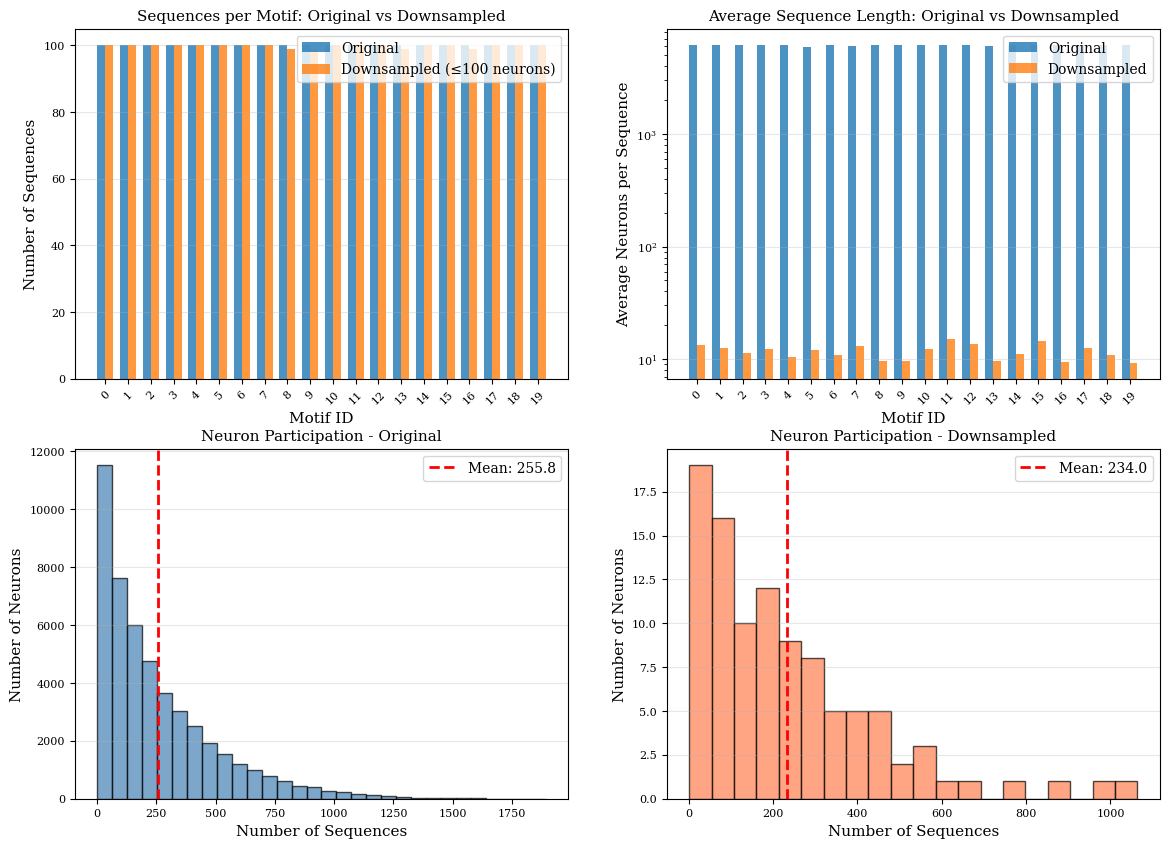

In [5]:
# Visualize the downsampling effect
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Sequences per motif
motif_ids = sorted(sequences.keys())
orig_counts = [len(sequences[m]) for m in motif_ids]
down_counts = [len(seqs_downsampled_filtered[m]) for m in motif_ids]

ax = axes[0, 0]
x = np.arange(len(motif_ids))
width = 0.35
ax.bar(x - width/2, orig_counts, width, label='Original', alpha=0.8)
ax.bar(x + width/2, down_counts, width, label='Downsampled (≤100 neurons)', alpha=0.8)
ax.set_xlabel('Motif ID')
ax.set_ylabel('Number of Sequences')
ax.set_title('Sequences per Motif: Original vs Downsampled')
ax.set_xticks(x)
ax.set_xticklabels(motif_ids, rotation=45)
ax.legend()
ax.grid(axis='y', alpha=0.3)

# 2. Average neurons per sequence
avg_orig_per_motif = [np.mean([len(s) for s in sequences[m]]) for m in motif_ids]
avg_down_per_motif = [np.mean([len(s) for s in seqs_downsampled_filtered[m]]) if seqs_downsampled_filtered[m] else 0 
                       for m in motif_ids]

ax = axes[0, 1]
ax.bar(x - width/2, avg_orig_per_motif, width, label='Original', alpha=0.8)
ax.bar(x + width/2, avg_down_per_motif, width, label='Downsampled', alpha=0.8)
ax.set_xlabel('Motif ID')
ax.set_ylabel('Average Neurons per Sequence')
ax.set_title('Average Sequence Length: Original vs Downsampled')
ax.set_xticks(x)
ax.set_xticklabels(motif_ids, rotation=45)
ax.legend()
ax.set_yscale('log')
ax.grid(axis='y', alpha=0.3)

# 4. Neuron participation rate - Original sequences
ax = axes[1, 0]
neuron_participation_orig = {}
for motif_id in motif_ids:
    for seq in sequences[motif_id]:
        for neuron in seq:
            neuron_participation_orig[neuron] = neuron_participation_orig.get(neuron, 0) + 1

participation_counts_orig = list(neuron_participation_orig.values())
ax.hist(participation_counts_orig, bins=30, alpha=0.7, color='steelblue', edgecolor='black')
ax.axvline(np.mean(participation_counts_orig), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(participation_counts_orig):.1f}')
ax.set_xlabel('Number of Sequences')
ax.set_ylabel('Number of Neurons')
ax.set_title('Neuron Participation - Original')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# 5. Neuron participation rate - Downsampled sequences
ax = axes[1, 1]
neuron_participation_down = {}
for motif_id in motif_ids:
    for seq in seqs_downsampled_filtered[motif_id]:
        for neuron in seq:
            neuron_participation_down[neuron] = neuron_participation_down.get(neuron, 0) + 1

participation_counts_down = list(neuron_participation_down.values())
ax.hist(participation_counts_down, bins=20, alpha=0.7, color='coral', edgecolor='black')
ax.axvline(np.mean(participation_counts_down), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(participation_counts_down):.1f}')
ax.set_xlabel('Number of Sequences')
ax.set_ylabel('Number of Neurons')
ax.set_title('Neuron Participation - Downsampled')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.savefig(f'summary_{params['sigma_range']}_vol_{params['vol_param']}_volcorr_{params['rho_vol']}.jpg')
plt.savefig(f'summary_{params['sigma_range']}_vol_{params['vol_param']}_volcorr_{params['rho_vol']}.pdf')
plt.show()

In [ ]:
# 4. Summary statistics
ax = axes[1, 2]
ax.axis('off')

total_orig = sum(len(seqs) for seqs in sequences.values())
total_down = sum(len(seqs) for seqs in seqs_downsampled_filtered.values())

summary_text = f"""
DOWNSAMPLING SUMMARY
{'='*40}

Original Configuration:
  • Neurons: 50,000
  • Motifs: 20
  • Sequences per motif: 100
  • Total sequences: 2,000
  • Avg neurons/seq: {np.mean(avg_orig_per_motif):.1f}

Downsampled Configuration:
  • Neurons kept: 0-100 (101 total)
  • Total sequences: {total_down}
  • Sequences retained: {total_down/total_orig*100:.1f}%
  • Avg neurons/seq: {np.mean(avg_down_per_motif):.1f}

Result:
  • Nearly all sequences retained
  • Each sequence heavily compressed
  • Avg reduction: {np.mean(avg_orig_per_motif)/np.mean(avg_down_per_motif):.1f}x fewer neurons
"""
ax.text(0.1, 0.5, summary_text, fontfamily='monospace', fontsize=10, 
        verticalalignment='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()

Testing different n_neurons_keep values (with min_length=5)...

n_neurons_keep=   10 → 2 motifs retained (with min_length=5)
n_neurons_keep=   20 → 13 motifs retained (with min_length=5)
n_neurons_keep=   50 → 20 motifs retained (with min_length=5)
n_neurons_keep=  100 → 20 motifs retained (with min_length=5)
n_neurons_keep=  200 → 20 motifs retained (with min_length=5)
n_neurons_keep=  500 → 20 motifs retained (with min_length=5)
n_neurons_keep= 1000 → 20 motifs retained (with min_length=5)
n_neurons_keep= 2000 → 20 motifs retained (with min_length=5)
n_neurons_keep= 5000 → 20 motifs retained (with min_length=5)


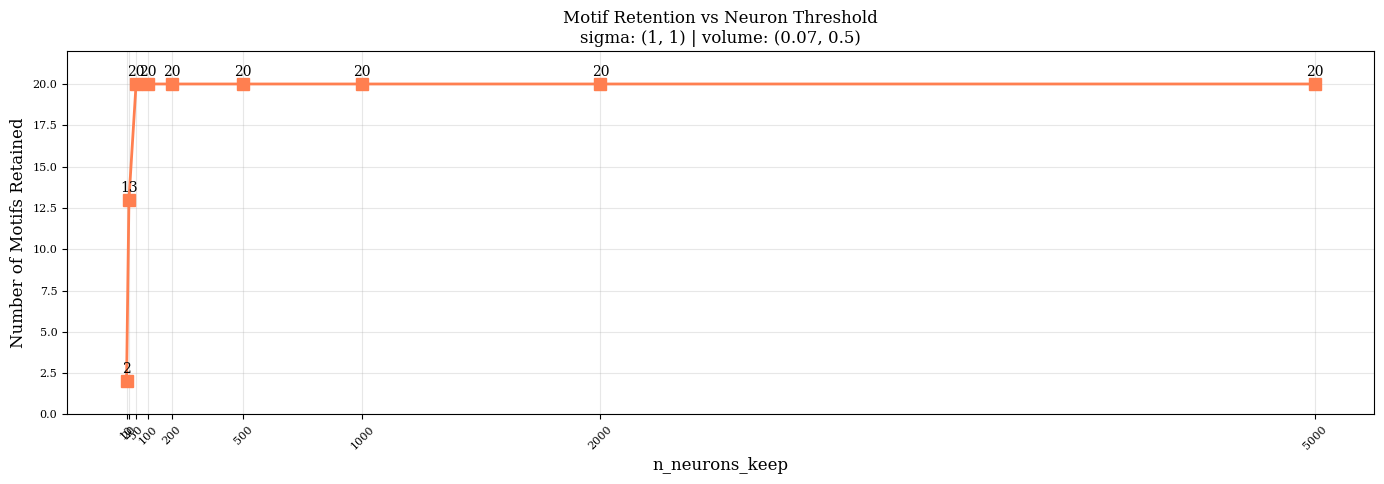

In [6]:
# Test different n_neurons_keep values and count motifs (with min_length=5 filter)
n_neurons_keep_values = [10, 20, 50, 100, 200, 500, 1000, 2000, 5000]
motif_counts_filtered = []

print("Testing different n_neurons_keep values (with min_length=5)...\n")
for n_keep in n_neurons_keep_values:
    seqs_down, _, _ = downsample_sequences(sequences, spk_times, volume, n_keep, min_length=5)
    
    # Count motifs that have at least one sequence
    motifs_with_seqs = sum(1 for motif_id, seqs in seqs_down.items() if len(seqs) > 0)
    motif_counts_filtered.append(motifs_with_seqs)
    
    print(f"n_neurons_keep={n_keep:5d} → {motifs_with_seqs} motifs retained (with min_length=5)")

# Plot
fig, ax = plt.subplots(figsize=(14, 5))

# Plot 2: With min_length=5 filter
ax.plot(n_neurons_keep_values, motif_counts_filtered, marker='s', linewidth=2, 
         markersize=8, color='coral', label='min_length=5')
ax.set_xlabel('n_neurons_keep', fontsize=12)
ax.set_ylabel('Number of Motifs Retained', fontsize=12)
ax.set_title(f'Motif Retention vs Neuron Threshold\nsigma: {params["sigma_range"]} | volume: {params["vol_param"]}', fontsize=12,)
ax.grid(True, alpha=0.3)
ax.set_xticks(n_neurons_keep_values)
ax.set_xticklabels(n_neurons_keep_values, rotation=45)
ax.set_ylim([0, 22])

# Add value labels on both plots
for x, y in zip(n_neurons_keep_values, motif_counts_filtered):
    ax.text(x, y + 0.3, str(int(y)), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig(f'motifnum_{params['sigma_range']}_vol_{params['vol_param']}_volcorr_{params['rho_vol']}.jpg')
plt.savefig(f'motifnum_{params['sigma_range']}_vol_{params['vol_param']}_volcorr_{params['rho_vol']}.pdf')
plt.show()


In [13]:
%reload_ext autoreload

In [7]:
# Convert dict to flat list for allmot
seqs_flat = []
for motif_id in sorted(seqs_downsampled_filtered.keys()):
    seqs_flat.extend(seqs_downsampled_filtered[motif_id])

print(f"Total sequences (flat): {len(seqs_flat)}")
print(f"Expected from filtered: {sum(len(seqs) for seqs in seqs_downsampled_filtered.values())}")

# Now run allmot
rep_index_down, nsig_down, pval_down, bmat_down, zmat_down, corrmat_down = rs.allmot(seqs_flat, nrm)
print("Done!")

Total sequences (flat): 1996
Expected from filtered: 1996
Done!


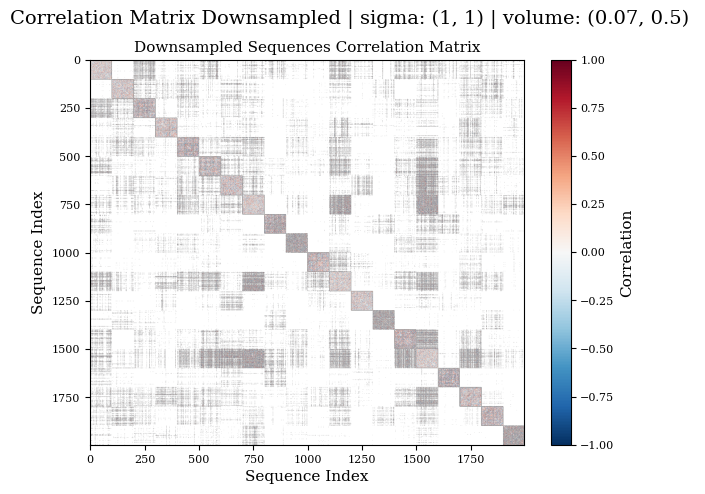

In [8]:
plt.figure(figsize=(7, 5))
plt.imshow(corrmat_down, aspect='auto', cmap='RdBu_r')
plt.colorbar(label='Correlation')
plt.title('Downsampled Sequences Correlation Matrix')
plt.xlabel('Sequence Index')
plt.ylabel('Sequence Index')    
plt.suptitle(f'Correlation Matrix Downsampled | sigma: {params["sigma_range"]} | volume: {params["vol_param"]} ', fontsize=14)
plt.savefig(f'corrmat_{params['sigma_range']}_vol_{params['vol_param']}_volcorr_{params['rho_vol']}.jpg')
plt.savefig(f'corrmat_{params['sigma_range']}_vol_{params['vol_param']}_volcorr_{params['rho_vol']}.pdf')
plt.show()

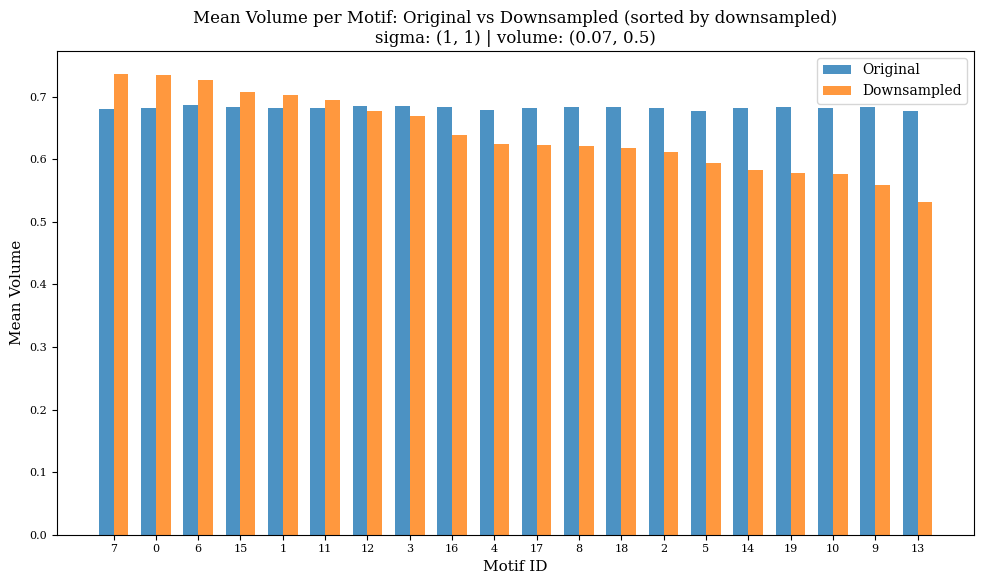

In [9]:
# get mean volume of downsampled sequences compared to original per motif and plot in one plot
# volume is shape (n_neurons, n_motifs)
# For each motif, compute the mean volume across all neurons that appear in sequences for that motif

mean_volume_orig = {
    m: np.mean([volume[neuron, m] for seq in sequences[m] for neuron in seq]) 
    for m in sequences
}

mean_volume_down = {
    m: np.mean([volume[neuron, m] for seq in seqs_downsampled_filtered[m] for neuron in seq]) 
    if seqs_downsampled_filtered[m] else 0 
    for m in seqs_downsampled_filtered
}

plt.figure(figsize=(10, 6))
# Sort by highest downsampled mean first
motif_ids = sorted(seqs_downsampled_filtered.keys())
sorted_indices = np.argsort([mean_volume_down[m] for m in motif_ids])[::-1]  # Descending order
motif_ids_sorted = [motif_ids[i] for i in sorted_indices]

x = np.arange(len(motif_ids_sorted))
width = 0.35
plt.bar(x - width/2, [mean_volume_orig[m] for m in motif_ids_sorted], width, label='Original', alpha=0.8)
plt.bar(x + width/2, [mean_volume_down[m] for m in motif_ids_sorted], width, label='Downsampled', alpha=0.8)
plt.xlabel('Motif ID')
plt.xticks(x, motif_ids_sorted)
plt.ylabel('Mean Volume')
plt.title(f'Mean Volume per Motif: Original vs Downsampled (sorted by downsampled)\nsigma: {params["sigma_range"]} | volume: {params["vol_param"]}', fontsize=12)
plt.legend()
plt.tight_layout()
plt.savefig(f'mean_volume_{params['sigma_range']}_vol_{params['vol_param']}_volcorr_{params['rho_vol']}.jpg')
plt.savefig(f'mean_volume_{params['sigma_range']}_vol_{params['vol_param']}_volcorr_{params['rho_vol']}.pdf')
plt.show()


In [10]:
from scripts.simulation.correlation_mean import add_within_clust_score

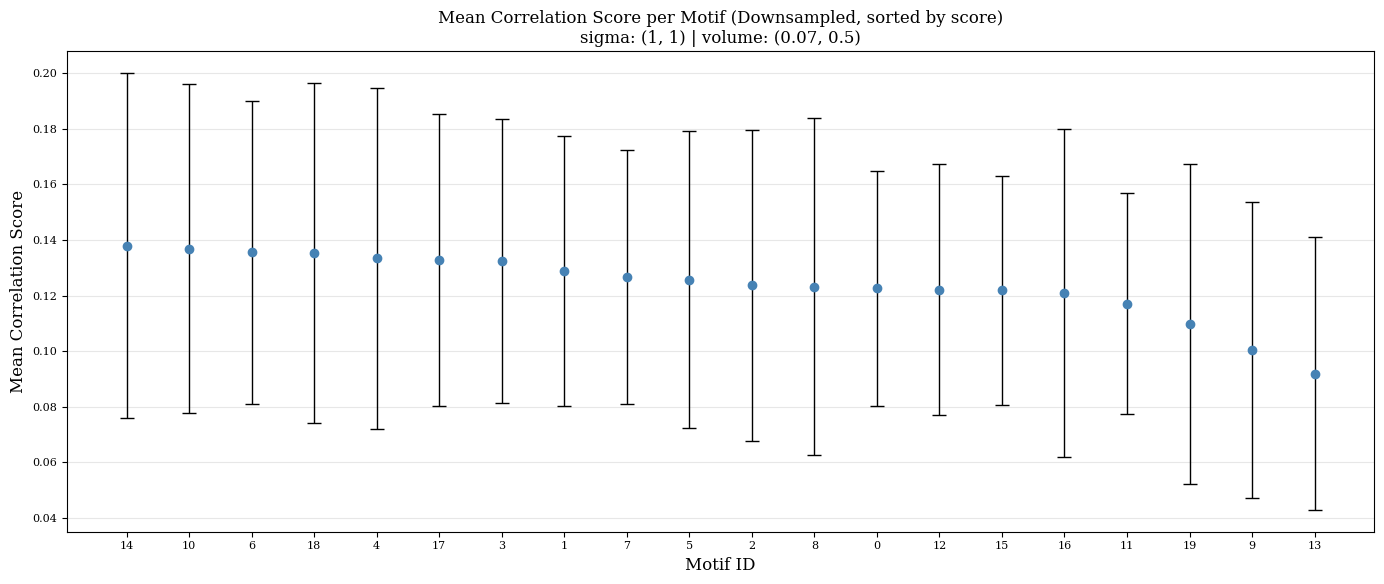

In [11]:
# Create motif index array to track which motif each sequence belongs to
motif_index_down = []
for motif_id in sorted(seqs_downsampled_filtered.keys()):
    motif_index_down.extend([motif_id] * len(seqs_downsampled_filtered[motif_id]))
motif_index_down = np.array(motif_index_down)

# Compute mean correlation per motif using the imported function
within_score, within_var = add_within_clust_score(motif_index_down, corrmat_down, bmat_down)

# Create proper mapping from unique motif IDs to scores
unique_motifs = np.unique(motif_index_down)
motif_to_score = {motif: score for motif, score in zip(unique_motifs, within_score)}
motif_to_var = {motif: var for motif, var in zip(unique_motifs, within_var)}

# Sort by highest score first (excluding NaN)
valid_motifs = [m for m in unique_motifs if not np.isnan(motif_to_score[m])]
sorted_motifs = sorted(valid_motifs, key=lambda m: motif_to_score[m], reverse=True)
scores_sorted = [motif_to_score[m] for m in sorted_motifs]
vars_sorted = [motif_to_var[m] for m in sorted_motifs]

# Plot
fig, ax = plt.subplots(figsize=(14, 6))
ax.errorbar(range(len(sorted_motifs)), scores_sorted, yerr=vars_sorted, fmt='o', color='steelblue', ecolor='black', capsize=5)
ax.set_xlabel('Motif ID', fontsize=12)
ax.set_ylabel('Mean Correlation Score', fontsize=12)
ax.set_title(f'Mean Correlation Score per Motif (Downsampled, sorted by score)\nsigma: {params["sigma_range"]} | volume: {params["vol_param"]}', fontsize=12)
ax.set_xticks(range(len(sorted_motifs)))
ax.set_xticklabels(sorted_motifs)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(f'mean_corr_score_{params['sigma_range']}_vol_{params['vol_param']}_volcorr_{params['rho_vol']}.jpg')
plt.savefig(f'mean_corr_score_{params['sigma_range']}_vol_{params['vol_param']}_volcorr_{params['rho_vol']}.pdf')
plt.show()


Processing n_keep=10...
Processing n_keep=20...
Processing n_keep=50...
Processing n_keep=100...
Processing n_keep=200...
Processing n_keep=500...
Processing n_keep=1000...


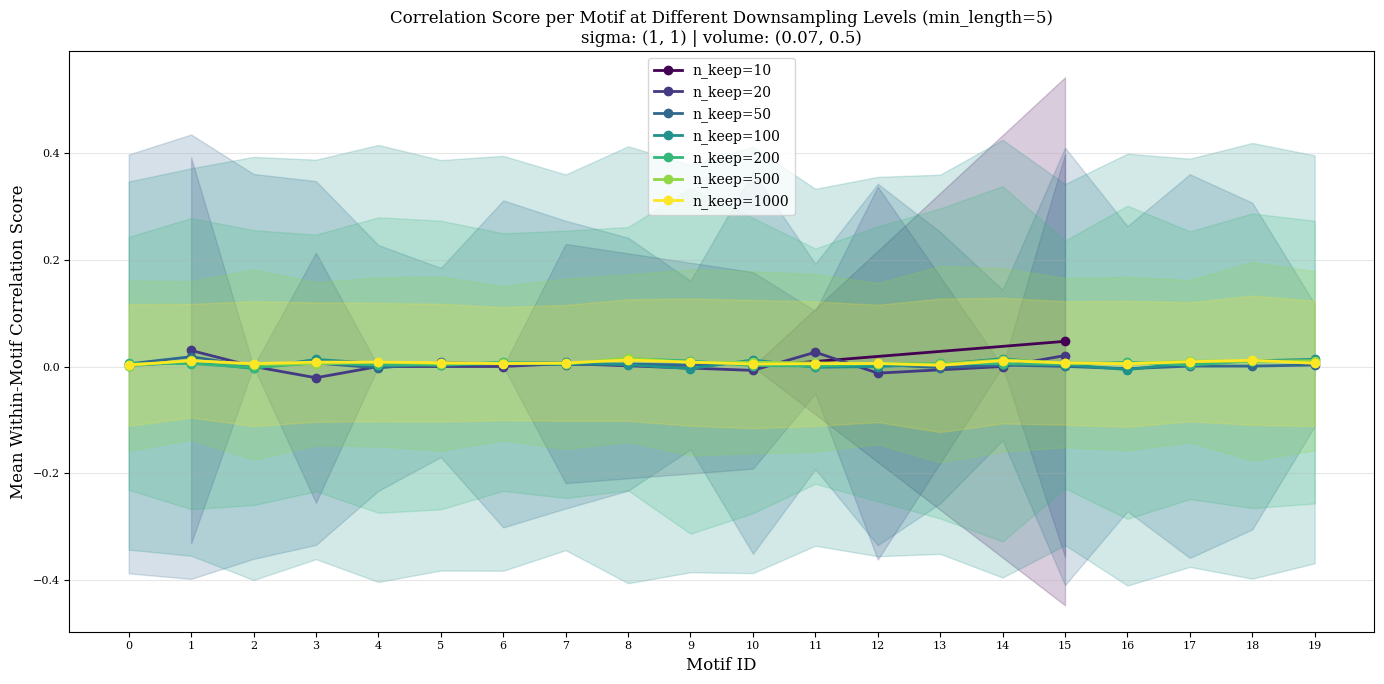

In [12]:
# Analyze how mean correlation scores change across different n_neurons_keep values
n_neurons_keep_values = [10, 20, 50, 100, 200, 500, 1000]
scores_per_keep = {}  # {n_keep: {motif_id: score}}
vars_per_keep = {}    # {n_keep: {motif_id: var}}

for n_keep in n_neurons_keep_values:
    print(f"Processing n_keep={n_keep}...")
    seqs_down, _, _ = downsample_sequences(sequences, spk_times, volume, n_keep, min_length=5)
    
    # Create motif index array
    motif_index = []
    for motif_id in sorted(seqs_down.keys()):
        motif_index.extend([motif_id] * len(seqs_down[motif_id]))
    
    if not motif_index:
        print(f"  No sequences for n_keep={n_keep}")
        continue
    
    motif_index = np.array(motif_index)
    
    # Flatten sequences for correlation computation
    seqs_flat = []
    for motif_id in sorted(seqs_down.keys()):
        seqs_flat.extend(seqs_down[motif_id])
    
    # Compute correlation matrix
    _, _, _, _, _, corrmat = rs.allmot(seqs_flat, nrm)
    
    # Compute within-motif correlation scores with proper mapping
    within_score, within_var = add_within_clust_score(motif_index, corrmat, None)
    
    # Create proper mapping from unique motif IDs to scores/vars
    unique_motifs = np.unique(motif_index)
    motif_to_score = {motif: score for motif, score in zip(unique_motifs, within_score)}
    motif_to_var = {motif: var for motif, var in zip(unique_motifs, within_var)}
    
    scores_per_keep[n_keep] = motif_to_score
    vars_per_keep[n_keep] = motif_to_var

# Plot: correlation scores per motif for each n_keep (one line per n_keep)
fig, ax = plt.subplots(figsize=(14, 7))

# Get all motif IDs that appear across all n_keep values
all_motifs = sorted(set().union(*[set(scores_per_keep[n].keys()) for n in scores_per_keep.keys()]))

# Color map for different n_keep values
colors = plt.cm.viridis(np.linspace(0, 1, len(n_neurons_keep_values)))

for i, n_keep in enumerate(n_neurons_keep_values):
    if n_keep not in scores_per_keep:
        continue
    
    # Get scores and vars for each motif
    motif_scores = []
    motif_vars = []
    motif_ids_present = []
    
    for motif_id in all_motifs:
        if motif_id in scores_per_keep[n_keep]:
            score = scores_per_keep[n_keep][motif_id]
            var = vars_per_keep[n_keep][motif_id]
            # Only include valid (non-NaN) scores
            if not np.isnan(score):
                motif_scores.append(score)
                motif_vars.append(var)
                motif_ids_present.append(motif_id)
    
    if motif_scores:
        motif_scores = np.array(motif_scores)
        motif_vars = np.array(motif_vars)
        std_scores = np.sqrt(motif_vars)
        x_pos = np.array(motif_ids_present)  # Use actual motif IDs as x positions
        
        # Plot line and fill_between for std
        ax.plot(x_pos, motif_scores, 'o-', color=colors[i], linewidth=2, markersize=6, label=f'n_keep={n_keep}')
        ax.fill_between(x_pos, motif_scores - std_scores, motif_scores + std_scores, 
                        alpha=0.2, color=colors[i])

ax.set_xlabel('Motif ID', fontsize=12)
ax.set_ylabel('Mean Within-Motif Correlation Score', fontsize=12)
ax.set_title(f'Correlation Score per Motif at Different Downsampling Levels (min_length=5)\nsigma: {params["sigma_range"]} | volume: {params["vol_param"]}', fontsize=12)
ax.set_xticks(all_motifs)
ax.set_xticklabels(all_motifs)
ax.grid(True, alpha=0.3, axis='y')
ax.legend(loc='best', fontsize=10)
plt.tight_layout()
plt.savefig(f'corr_per_motif_vs_n_keep_{params["sigma_range"]}_vol_{params["vol_param"]}_volcorr_{params['rho_vol']}.jpg')
plt.savefig(f'corr_per_motif_vs_n_keep_{params["sigma_range"]}_vol_{params["vol_param"]}_volcorr_{params['rho_vol']}.pdf')
plt.show()



In [13]:
# Debug: Check n_keep=10 specifically
print("=" * 60)
print("DETAILED ANALYSIS OF n_keep=10")
print("=" * 60)

if 10 in scores_per_keep:
    print(f"\nMotifs with data at n_keep=10: {list(scores_per_keep[10].keys())}")
    print(f"\nScores and variances:")
    for motif_id in sorted(scores_per_keep[10].keys()):
        score = scores_per_keep[10][motif_id]
        var = vars_per_keep[10][motif_id]
        std = np.sqrt(var)
        print(f"  Motif {motif_id:2d}: score={score:8.6f}, var={var:8.6f}, std={std:8.6f}")
else:
    print("n_keep=10 has no data in scores_per_keep!")

# Check which n_keep values have motif 15
print("\n" + "=" * 60)
print("MOTIF 15 ACROSS ALL n_keep VALUES")
print("=" * 60)
for n_keep in n_neurons_keep_values:
    if n_keep in scores_per_keep and 15 in scores_per_keep[n_keep]:
        score = scores_per_keep[n_keep][15]
        var = vars_per_keep[n_keep][15]
        print(f"n_keep={n_keep:4d}: Motif 15 score={score:8.6f}, var={var:8.6f}")
    else:
        print(f"n_keep={n_keep:4d}: Motif 15 NOT present")


DETAILED ANALYSIS OF n_keep=10

Motifs with data at n_keep=10: [np.int64(10), np.int64(15)]

Scores and variances:
  Motif 10: score=0.000000, var=0.000000, std=0.000000
  Motif 15: score=0.047059, var=0.243537, std=0.493495

MOTIF 15 ACROSS ALL n_keep VALUES
n_keep=  10: Motif 15 score=0.047059, var=0.243537
n_keep=  20: Motif 15 score=0.020464, var=0.141737
n_keep=  50: Motif 15 score=0.000171, var=0.167198
n_keep= 100: Motif 15 score=0.003572, var=0.113890
n_keep= 200: Motif 15 score=0.003760, var=0.053615
n_keep= 500: Motif 15 score=0.007273, var=0.025040
n_keep=1000: Motif 15 score=0.006613, var=0.013319


In [14]:
# Find motifs with correlation > 0.4 and their mean volumes
print("=" * 80)
print("MOTIFS WITH CORRELATION > 0.4 AND THEIR MEAN VOLUMES")
print("=" * 80)

high_corr_summary = {}  # {n_keep: [(motif_id, correlation_score, mean_volume), ...]}

for n_keep in n_neurons_keep_values:
    if n_keep not in scores_per_keep:
        print(f"\nn_keep={n_keep}: No data")
        continue
    
    # Find motifs with correlation > 0.4
    high_corr_motifs = []
    for motif_id in sorted(scores_per_keep[n_keep].keys()):
        score = scores_per_keep[n_keep][motif_id]
        if not np.isnan(score) and score > 0.4:
            high_corr_motifs.append((motif_id, score))
    
    if high_corr_motifs:
        # Recompute mean volume for this n_keep
        seqs_down, _, _ = downsample_sequences(sequences, spk_times, volume, n_keep, min_length=5)
        
        results = []
        for motif_id, score in high_corr_motifs:
            if seqs_down[motif_id]:
                mean_vol = np.mean([volume[neuron, motif_id] for seq in seqs_down[motif_id] for neuron in seq])
                results.append((motif_id, score, mean_vol))
        
        high_corr_summary[n_keep] = results
        print(f"\nn_keep={n_keep} ({len(results)} motifs with corr > 0.4):")
        for motif_id, score, mean_vol in results:
            print(f"  Motif {motif_id:2d}: corr={score:.6f}, mean_vol={mean_vol:.6f}")
    else:
        print(f"\nn_keep={n_keep}: No motifs with correlation > 0.4")
        high_corr_summary[n_keep] = []

print("\n" + "=" * 80)
print("SUMMARY TABLE")
print("=" * 80)
for n_keep in n_neurons_keep_values:
    n_motifs = len(high_corr_summary.get(n_keep, []))
    print(f"n_keep={n_keep:4d}: {n_motifs} motifs with corr > 0.4")


MOTIFS WITH CORRELATION > 0.4 AND THEIR MEAN VOLUMES

n_keep=10: No motifs with correlation > 0.4

n_keep=20: No motifs with correlation > 0.4

n_keep=50: No motifs with correlation > 0.4

n_keep=100: No motifs with correlation > 0.4

n_keep=200: No motifs with correlation > 0.4

n_keep=500: No motifs with correlation > 0.4

n_keep=1000: No motifs with correlation > 0.4

SUMMARY TABLE
n_keep=  10: 0 motifs with corr > 0.4
n_keep=  20: 0 motifs with corr > 0.4
n_keep=  50: 0 motifs with corr > 0.4
n_keep= 100: 0 motifs with corr > 0.4
n_keep= 200: 0 motifs with corr > 0.4
n_keep= 500: 0 motifs with corr > 0.4
n_keep=1000: 0 motifs with corr > 0.4


/tmp/ipykernel_73523/1680260707.py:49: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  im2 = ax2.imshow(heatmap_volumes, cmap='viridis', aspect='auto')


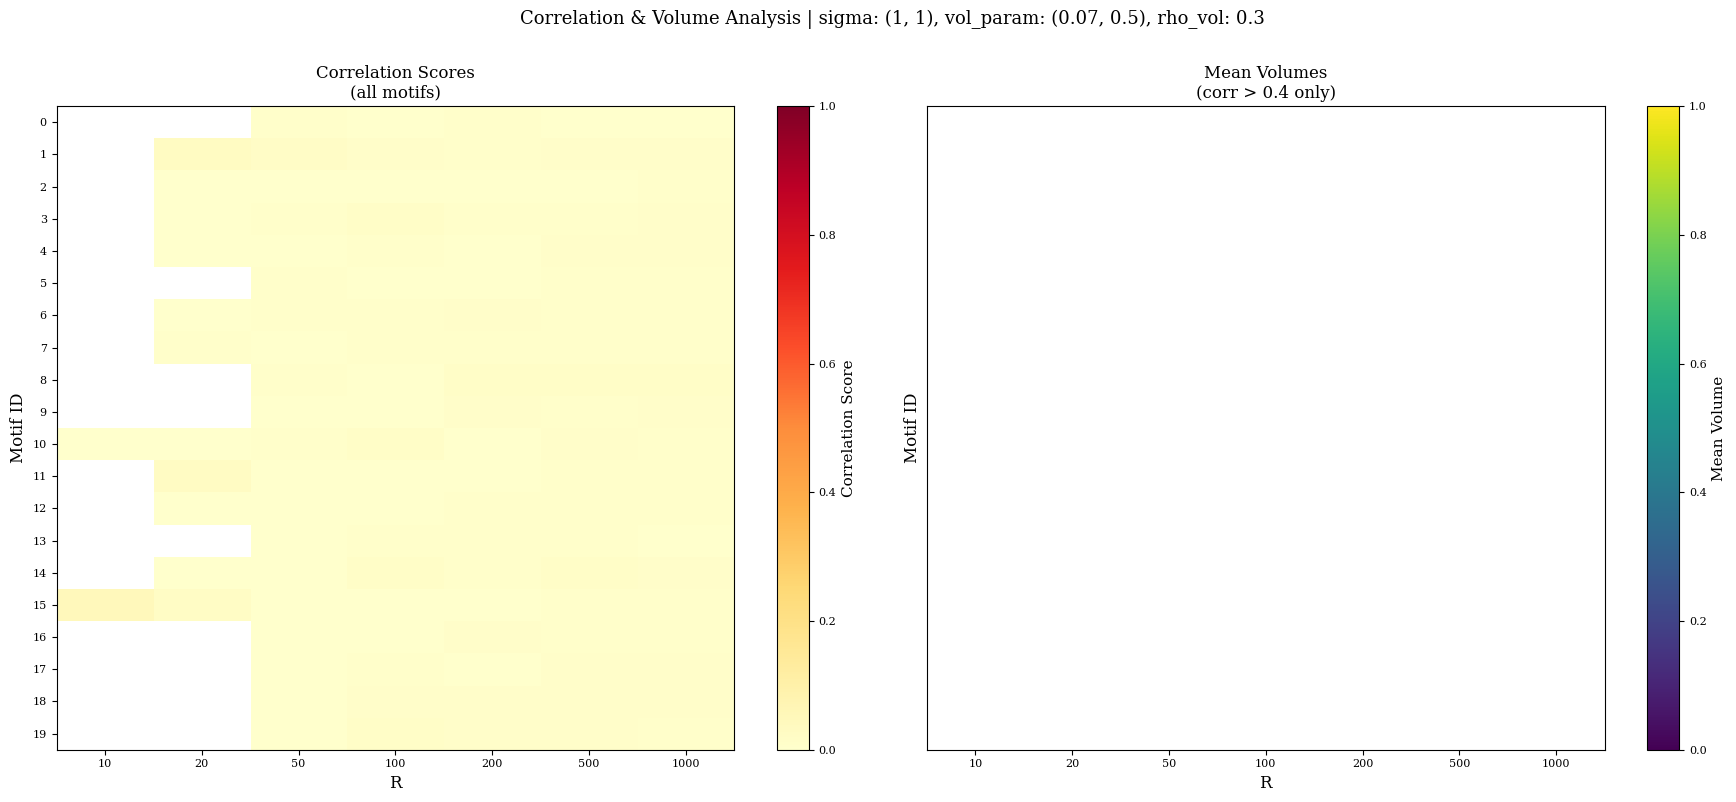

In [15]:
# Visualize correlation scores and mean volumes as side-by-side subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# === LEFT SUBPLOT: All correlation scores ===
# Get all motif IDs that appear across all n_keep values
all_motifs_heatmap = sorted(set().union(*[set(scores_per_keep[n].keys()) for n in scores_per_keep.keys()]))

# Use only n_keep values that have data
n_keep_vals_with_data = [n for n in n_neurons_keep_values if n in scores_per_keep]

# Create heatmap with all correlation scores
heatmap_data_all = np.full((len(all_motifs_heatmap), len(n_keep_vals_with_data)), np.nan)
for col_idx, n_keep in enumerate(n_keep_vals_with_data):
    for row_idx, motif_id in enumerate(all_motifs_heatmap):
        if motif_id in scores_per_keep[n_keep]:
            score = scores_per_keep[n_keep][motif_id]
            if not np.isnan(score):
                heatmap_data_all[row_idx, col_idx] = score

im1 = ax1.imshow(heatmap_data_all, cmap='YlOrRd', aspect='auto', vmin=0, vmax=1)
ax1.set_xticks(range(len(n_keep_vals_with_data)))
ax1.set_xticklabels(n_keep_vals_with_data)
ax1.set_yticks(range(len(all_motifs_heatmap)))
ax1.set_yticklabels(all_motifs_heatmap)
ax1.set_xlabel('R', fontsize=12)
ax1.set_ylabel('Motif ID', fontsize=12)
ax1.set_title('Correlation Scores\n(all motifs)', fontsize=12)
cbar1 = plt.colorbar(im1, ax=ax1, label='Correlation Score')

# === RIGHT SUBPLOT: Mean volumes for high-correlation motifs ===
# Get all motifs that have correlation > 0.4 in at least one n_keep
all_high_corr_motifs_vol = sorted(set().union(*[
    set(motif_id for motif_id, _, _ in high_corr_summary[n_keep]) 
    for n_keep in high_corr_summary.keys() if high_corr_summary[n_keep]
]))

# Use only n_keep values that have data
n_keep_vals_with_data_vol = [n for n in n_neurons_keep_values if n in high_corr_summary]

# Create heatmap with mean volumes
heatmap_volumes = np.full((len(all_high_corr_motifs_vol), len(n_keep_vals_with_data_vol)), np.nan)
for col_idx, n_keep in enumerate(n_keep_vals_with_data_vol):
    for row_idx, motif_id in enumerate(all_high_corr_motifs_vol):
        for m_id, score, mean_vol in high_corr_summary[n_keep]:
            if m_id == motif_id:
                heatmap_volumes[row_idx, col_idx] = mean_vol
                break

im2 = ax2.imshow(heatmap_volumes, cmap='viridis', aspect='auto')
ax2.set_xticks(range(len(n_keep_vals_with_data_vol)))
ax2.set_xticklabels(n_keep_vals_with_data_vol)
ax2.set_yticks(range(len(all_high_corr_motifs_vol)))
ax2.set_yticklabels(all_high_corr_motifs_vol)
ax2.set_xlabel('R', fontsize=12)
ax2.set_ylabel('Motif ID', fontsize=12)
ax2.set_title('Mean Volumes\n(corr > 0.4 only)', fontsize=12)
cbar2 = plt.colorbar(im2, ax=ax2, label='Mean Volume')

fig.suptitle(f'Correlation & Volume Analysis | sigma: {params["sigma_range"]}, vol_param: {params["vol_param"]}, rho_vol: {params["rho_vol"]}', 
             fontsize=13, y=1.00)

plt.tight_layout()
plt.savefig(f'corr_and_volumes_combined_{params["sigma_range"]}_vol_{params["vol_param"]}_volcorr_{params["rho_vol"]}.jpg', bbox_inches='tight')
plt.savefig(f'corr_and_volumes_combined_{params["sigma_range"]}_vol_{params["vol_param"]}_volcorr_{params["rho_vol"]}.pdf', bbox_inches='tight')
plt.show()

In [2]:
# PARAMETERS
params = {
    "n_neurons": 50000,
    "n_motifs": 20,
    "n_bins": 100,
    "n_sequences": 100,
    "sigma_range": (1,1),    # increasing range makes sequences less similar
    "vol_param": (0.07, 0.9),     # beta distribution:  0.07, 0.9
                                  # a inactive (lower -> more neurons inactive, if high longer seqs, mean len shifts)
                                  # b active (lower -> more neurons active, if <1, skewed to 1, if lower longer seqs, mean len shifts)
    "corr_mu": False,
    "rho_mu": 0.0,
    "corr_sigma": False,
    "rho_sig": 0.0,
    "corr_volume": False,
    "rho_vol": 0.0,
    "shuffle_order": False,       # shuffle order of sequences

}

In [3]:
seqs, seqs_labels, spk_times, sequences, true_templates, mu, sigma, volume, densities, cdfs = simulate_sequences(**params, random_state=2, plot=False, batch_size=5000)

Processed batch: neurons 0-5000/50000
Processed batch: neurons 5000-10000/50000
Processed batch: neurons 10000-15000/50000
Processed batch: neurons 15000-20000/50000
Processed batch: neurons 20000-25000/50000
Processed batch: neurons 25000-30000/50000
Processed batch: neurons 30000-35000/50000
Processed batch: neurons 35000-40000/50000
Processed batch: neurons 40000-45000/50000
Processed batch: neurons 45000-50000/50000
Generated sequences for motif 0/20
Generated sequences for motif 1/20
Generated sequences for motif 2/20
Generated sequences for motif 3/20
Generated sequences for motif 4/20
Generated sequences for motif 5/20
Generated sequences for motif 6/20
Generated sequences for motif 7/20
Generated sequences for motif 8/20
Generated sequences for motif 9/20
Generated sequences for motif 10/20
Generated sequences for motif 11/20
Generated sequences for motif 12/20
Generated sequences for motif 13/20
Generated sequences for motif 14/20
Generated sequences for motif 15/20
Generated 

Testing different n_neurons_keep values (with min_length=5)...

n_neurons_keep=   10 → 0 motifs retained (with min_length=5)
n_neurons_keep=   20 → 5 motifs retained (with min_length=5)
n_neurons_keep=   50 → 19 motifs retained (with min_length=5)
n_neurons_keep=  100 → 20 motifs retained (with min_length=5)
n_neurons_keep=  200 → 20 motifs retained (with min_length=5)
n_neurons_keep=  500 → 20 motifs retained (with min_length=5)
n_neurons_keep= 1000 → 20 motifs retained (with min_length=5)
n_neurons_keep= 2000 → 20 motifs retained (with min_length=5)
n_neurons_keep= 5000 → 20 motifs retained (with min_length=5)


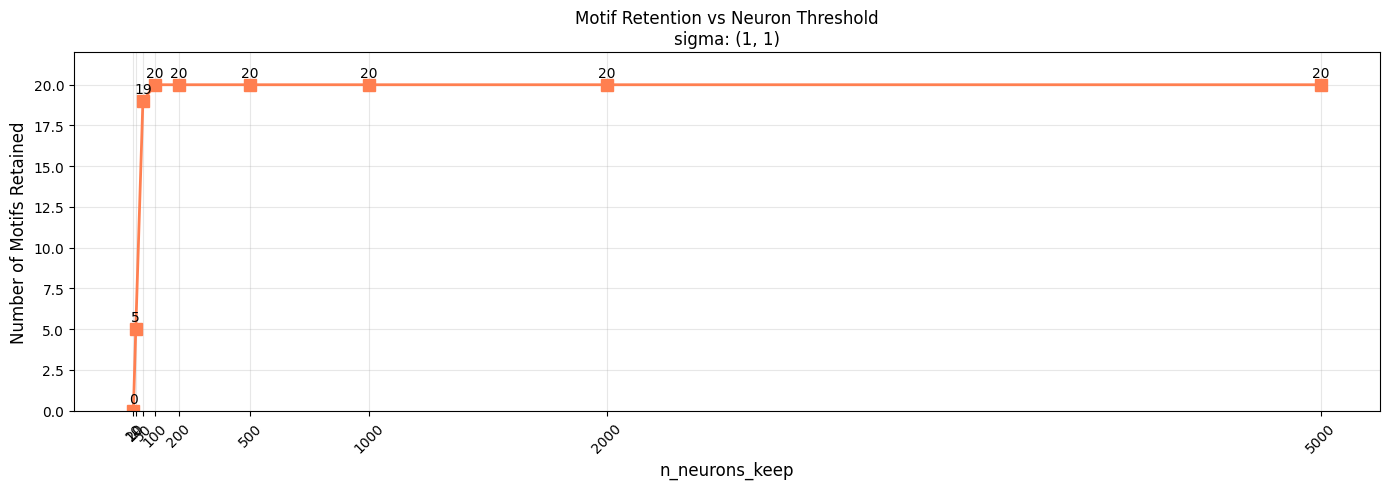

In [16]:
# Test different n_neurons_keep values and count motifs (with min_length=5 filter)
n_neurons_keep_values = [10, 20, 50, 100, 200, 500, 1000, 2000, 5000]
motif_counts_filtered = []

print("Testing different n_neurons_keep values (with min_length=5)...\n")
for n_keep in n_neurons_keep_values:
    seqs_down, _, _ = downsample_sequences(sequences, spk_times, volume, n_keep, min_length=5)
    
    # Count motifs that have at least one sequence
    motifs_with_seqs = sum(1 for motif_id, seqs in seqs_down.items() if len(seqs) > 0)
    motif_counts_filtered.append(motifs_with_seqs)
    
    print(f"n_neurons_keep={n_keep:5d} → {motifs_with_seqs} motifs retained (with min_length=5)")

# Plot
fig, ax = plt.subplots(figsize=(14, 5))

# Plot 2: With min_length=5 filter
ax.plot(n_neurons_keep_values, motif_counts_filtered, marker='s', linewidth=2, 
         markersize=8, color='coral', label='min_length=5')
ax.set_xlabel('n_neurons_keep', fontsize=12)
ax.set_ylabel('Number of Motifs Retained', fontsize=12)
ax.set_title(f'Motif Retention vs Neuron Threshold\nsigma: {params["sigma_range"]}', fontsize=12,)
ax.grid(True, alpha=0.3)
ax.set_xticks(n_neurons_keep_values)
ax.set_xticklabels(n_neurons_keep_values, rotation=45)
ax.set_ylim([0, 22])

# Add value labels on both plots
for x, y in zip(n_neurons_keep_values, motif_counts_filtered):
    ax.text(x, y + 0.3, str(int(y)), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:
seqs_downsampled_filtered, spk_times_downsampled_filtered, volume_downsampled_filtered = downsample_sequences(sequences, spk_times, volume, 100, min_length=5)

seqs_flat = []
for motif_id in sorted(seqs_downsampled_filtered.keys()):
    seqs_flat.extend(seqs_downsampled_filtered[motif_id])

rep_index_down, nsig_down, pval_down, bmat_down, zmat_down, corrmat_down = rs.allmot(seqs_flat, nrm)


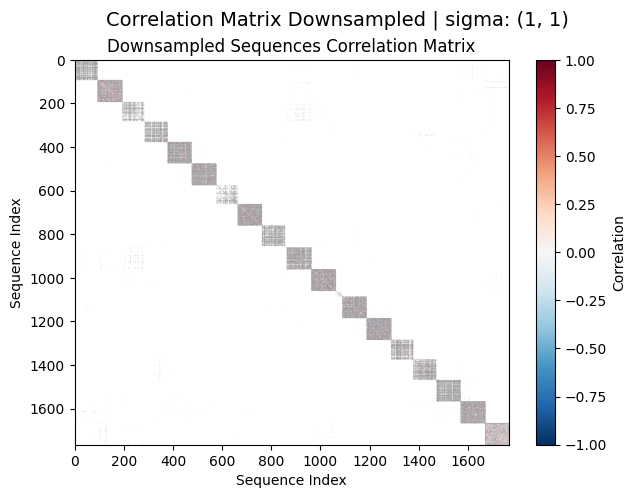

In [15]:
plt.figure(figsize=(7, 5))
plt.imshow(corrmat_down, aspect='auto', cmap='RdBu_r')
plt.colorbar(label='Correlation')
plt.title('Downsampled Sequences Correlation Matrix')
plt.xlabel('Sequence Index')
plt.ylabel('Sequence Index')    
plt.suptitle(f'Correlation Matrix Downsampled | sigma: {params["sigma_range"]}', fontsize=14)
plt.show()